<a href="https://colab.research.google.com/github/aadyakoirala/analytics-projects/blob/main/GB657_WineQuality_RF_GB_Koirala_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Predicting High-Quality Wines via Random Forest and Boosting Ensembles
Author: Aadya Koirala

Course: GEN BUS 657 — Data Insights & Analytics

Project: Predicting High-Quality Wines via Random Forest and Boosting Ensembles

## Introduction
This project applies ensemble learning methods to predict high-quality wines using the Wine Quality dataset previously explored in earlier modules. Building on the classification tree analysis from M3, the goal is to evaluate whether more advanced tree-based ensembles—specifically Random Forests and Boosted Trees—offer improved predictive performance for identifying wines that are “out of the ordinary” for the head purchaser. Using the same data split and preprocessing setup as before ensures a fair and consistent comparison across models.
Both ensemble learners are trained on the binary classification task, and their performance is assessed using confusion matrices, ROC curves, and AUC values on the test set. These results are then compared to the pruned classification tree from M3 to determine whether ensemble methods provide meaningful gains in accuracy, stability, and overall predictive power for high-quality wine detection.


## Importing Required Libraries
In this section, I load all the Python libraries needed for data handling, model training, and evaluation. NumPy and pandas support data manipulation, while Matplotlib and Seaborn are used for visualizing results such as ROC curves. The scikit-learn modules provide tools for splitting the data, fitting ensemble models (Random Forests and Boosted Trees), and computing evaluation metrics including confusion matrices and AUC values. These libraries form the foundation for building and assessing the ensemble learners used to predict high-quality wines.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import mean_squared_error,confusion_matrix, classification_report, roc_curve, auc, roc_auc_score

In [ ]:
!git clone https://github.com/danielbauer1979/MSDIA_PredictiveModelingAndMachineLearning.git

fatal: destination path 'MSDIA_PredictiveModelingAndMachineLearning' already exists and is not an empty directory.


In [ ]:
wine_dat = pd.read_csv('MSDIA_PredictiveModelingAndMachineLearning/GB886_VIII_4_winequality.csv')

In [ ]:
wine_dat

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,0
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,0
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,0
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,0


In [ ]:
wine_dat.shape

(1599, 12)

## Data Cleaning
For this assignment, the only data cleaning step required was checking the dataset for duplicate rows. Since the wine dataset has already been validated in previous modules, no additional preprocessing (such as handling missing values or adjusting data types) was necessary.


## Duplicate Check

In [ ]:
## Check for duplicates
wine_dat.duplicated().sum()

np.int64(240)


The dataset contained 240 duplicate rows. Since duplicates can bias clustering results by overweighting repeated observations, we removed them using drop_duplicates().




## Removing Duplicates






In [ ]:
## Remove duplicates if any
wine_dat = wine_dat.drop_duplicates()

In [ ]:
wine_dat.shape

(1359, 12)

After removing duplicates, the cleaned dataset contains 1,359 unique observations and 12 variables, and this version is used for all subsequent modeling steps.


## Exploring the Data
Before fitting ensemble models, I performed a brief exploratory analysis to understand the distribution of the wine features and the balance of the binary target variable. Since tree-based methods do not require feature scaling or transformation, the goal of this step was to confirm that the dataset behaves as expected and is suitable for Random Forest and Boosting models.

## Feature Distributions
The physicochemical features in the dataset (such as acidity levels, sulfur dioxide, density, pH, sulphates, and alcohol) exhibit a range of distribution shapes. Some variables are right-skewed, while others—such as alcohol—are more symmetric. These patterns are typical for this dataset and do not require preprocessing for tree-based learners.
To illustrate this, I generated a two-panel visualization for the alcohol feature:
- A histogram with a density curve, showing the overall distribution along with quartile and mean markers
- A log-scaled boxplot, highlighting the presence of mild outliers without distorting the main distribution
These visual checks confirm that the alcohol variable behaves smoothly and contains no extreme anomalies that would interfere with model training.

## Target Variable Balance
The quality column in this dataset is already encoded as a binary classification target:
- 1 = high-quality wine
- 0 = not high-quality wine
The classes are moderately imbalanced, with far fewer high-quality wines than non-high-quality wines. Because of this imbalance, evaluation metrics such as ROC curves and AUC are especially important for assessing model performance beyond simple accuracy.

## Visual Checks
To support the exploratory analysis, I generated:
- Histograms of key features
- A log-scaled boxplot of alcohol content
- A bar plot showing the distribution of the binary quality classes
These visualizations confirm that the dataset is clean, well-behaved, and ready for training ensemble models.


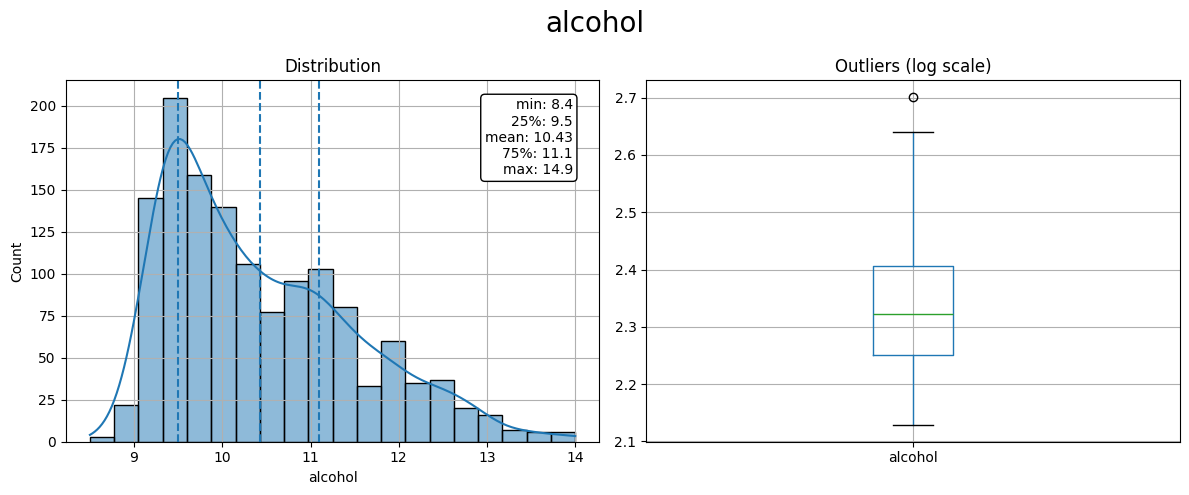

In [ ]:


# choose any feature, e.g., "alcohol"
x = "alcohol"

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,5), sharex=False, sharey=False)
fig.suptitle(x, fontsize=20)

# -----------------------------
# 1. Distribution Plot
# -----------------------------
ax[0].set_title('Distribution')

variable = wine_dat[x].copy()

# remove extreme tails for nicer plotting (optional)
breaks = np.quantile(variable, q=np.linspace(0, 1, 11))
variable = variable[(variable > breaks[0]) & (variable < breaks[10])]

sns.histplot(variable, kde=True, ax=ax[0])
des = wine_dat[x].describe()

# add vertical lines
ax[0].axvline(des["25%"], ls='--')
ax[0].axvline(des["mean"], ls='--')
ax[0].axvline(des["75%"], ls='--')
ax[0].grid(True)

# summary box
des_round = round(des, 2).apply(lambda x: str(x))
box = '\n'.join((
    "min: " + des_round["min"],
    "25%: " + des_round["25%"],
    "mean: " + des_round["mean"],
    "75%: " + des_round["75%"],
    "max: " + des_round["max"]
))
ax[0].text(
    0.95, 0.95, box,
    transform=ax[0].transAxes,
    fontsize=10,
    va='top', ha='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=1)
)

# -----------------------------
# 2. Boxplot (log scale)
# -----------------------------
ax[1].set_title('Outliers (log scale)')

tmp = pd.DataFrame(wine_dat[x])
tmp[x] = np.log(tmp[x] + 1e-6)  # avoid log(0)

tmp.boxplot(column=x, ax=ax[1])

plt.tight_layout()
plt.show()

The distribution of alcohol content in the wine dataset shows a slightly right-skewed pattern, with most wines falling between 9.5% and 11.5% alcohol and a mean of 10.43%. The histogram highlights that while the majority of wines cluster around the center of the distribution, a small number of higher‑alcohol wines extend the upper tail. The boxplot (shown on a log scale) confirms the presence of a few high-alcohol outliers, though these are expected and do not require removal because tree-based models are robust to such values. Overall, alcohol displays moderate variability and is known to be one of the strongest predictors of wine quality, making its distribution important for understanding how the ensemble models may use this feature during classification.




To understand the balance of the binary target variable, I examined the distribution of the quality column. Since this dataset already encodes wine quality as a 0/1 classification, checking the class counts helps confirm the level of imbalance and ensures that stratified sampling in the train–test split is appropriate.



In [ ]:
wine_dat["quality"].value_counts()

,count
quality,
0,1175
1,184


## Train–Test Split
To ensure a fair comparison with the models built in earlier modules, I used the same data‑splitting strategy as in M3. The binary quality column serves as the target variable, while all remaining physicochemical features form the predictor matrix. A stratified 75/25 train–test split was applied to preserve the proportion of high‑quality and non‑high‑quality wines in both sets. This split provides a consistent foundation for training the Random Forest and Boosted Tree models and for evaluating their performance on unseen data.


In [ ]:
X = wine_dat.drop(columns=["quality"])
y = wine_dat["quality"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

## Random Forest Model
 After preparing the data and creating the stratified train–test split, I fit a Random Forest classifier to the training set. Random Forests extend the idea of bagging by building many decision trees on bootstrap samples of the data and randomly selecting a subset of predictors at each split. This additional layer of randomness reduces correlation among the trees and typically improves predictive accuracy and model stability compared to a single decision tree.
For this model, I used 500 trees and the square‑root rule for the number of features considered at each split. The model was trained on the training set, and its performance was evaluated on the test set using predicted class labels and predicted probabilities. Key evaluation metrics include the confusion matrix, classification report, accuracy, and AUC, which together provide a comprehensive view of how well the Random Forest identifies high-quality wines.




In [ ]:
wine_rf = RandomForestClassifier(
    random_state=42,
    n_estimators=500,
    max_features="sqrt"
)

wine_rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=500, random_state=42)

After fitting the Random Forest model, I generated predictions on the test set. This includes both the predicted class labels, which are used for the confusion matrix and classification report, and the predicted probabilities for the positive class, which are required for computing the ROC curve and AUC.

In [ ]:
y_rf_test_pred = wine_rf.predict(X_test)

In [ ]:
y_rf_test_prob = wine_rf.predict_proba(X_test)[:, 1]

After generating both class predictions and predicted probabilities for the test set, I evaluated the Random Forest's performance using several standard classification metrics. The confusion matrix and classification report summarize how well the model distinguishes between high-quality and non-high-quality wines, while the overall accuracy provides a single-number measure of correctness. In addition, the predicted probabilities were used to compute the AUC, which reflects the model's ability to rank wines by their likelihood of being high quality. Together, these metrics offer a comprehensive assessment of the Random Forest's predictive performance on unseen data.

In [ ]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, roc_auc_score
)

print("Confusion Matrix (Test):")
print(confusion_matrix(y_test, y_rf_test_pred))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_rf_test_pred))

print("Accuracy:", round(accuracy_score(y_test, y_rf_test_pred), 3))

print("AUC:", round(roc_auc_score(y_test, y_rf_test_prob), 3))

Confusion Matrix (Test):
[[284  10]
 [ 30  16]]

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       294
           1       0.62      0.35      0.44        46

    accuracy                           0.88       340
   macro avg       0.76      0.66      0.69       340
weighted avg       0.87      0.88      0.87       340

Accuracy: 0.882
AUC: 0.875


The Random Forest model performs well overall, achieving an accuracy of 0.882 and an AUC of 0.875, indicating strong ability to rank wines by their likelihood of being high quality. The confusion matrix shows that the model correctly identifies most non-high-quality wines (284 true negatives) and makes relatively few false positives (10). This is reflected in the high precision (0.90) and recall (0.97) for class 0.
Performance on the high-quality class (class 1) is more modest. The model correctly identifies 16 high-quality wines but misses 30 of them, resulting in a recall of 0.35. However, its precision for class 1 (0.62) indicates that when the model predicts a wine is high quality, it is usually correct. This trade-off is common in imbalanced datasets, where the minority class is harder to detect.
The AUC of 0.875 suggests that, despite lower recall for class 1, the model separates the two classes well in probability space. Overall, the Random Forest substantially improves predictive stability and ranking performance compared to a single decision tree, even though identifying all high‑quality wines remains challenging due to class imbalance.


To better understand how the Random Forest model makes its predictions, I examined the feature importance scores derived from the trained ensemble. Random Forests measure importance based on the average reduction in impurity contributed by each feature across all trees. Higher values indicate predictors that play a larger role in distinguishing high-quality wines from non-high-quality wines. Plotting these importance scores provides insight into which physicochemical properties the model relies on most and helps validate whether the influential features align with domain expectations.

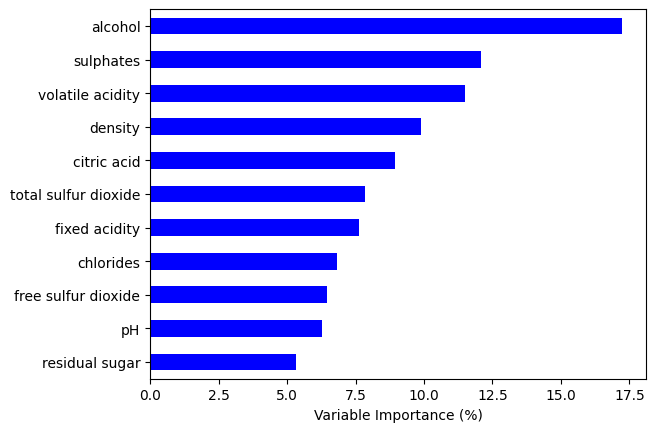

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Compute feature importance
Importance_ = pd.DataFrame(
    {'Importance': wine_rf.feature_importances_ * 100},
    index=X_train.columns
)

# Sort and take top 20
Importance = Importance_.sort_values('Importance', ascending=False).head(20)

# Plot
Importance.plot(kind='barh', color='b')
plt.xlabel('Variable Importance (%)')
plt.gca().invert_yaxis()
plt.gca().legend_ = None
plt.show()

## ROC Curve for the Random Forest Classifier
To visualize how well the Random Forest model separates high-quality wines from non-high-quality wines across all possible classification thresholds, I generated the ROC curve using the predicted probabilities for the positive class. The ROC curve plots the true positive rate against the false positive rate, providing a threshold-independent view of model performance. The Area Under the Curve (AUC) summarizes this performance into a single metric, with higher values indicating stronger discriminatory ability. This plot is required for comparing the Random Forest to the Boosted Tree and the pruned classification tree from M3.




## Let's look at the predictions:

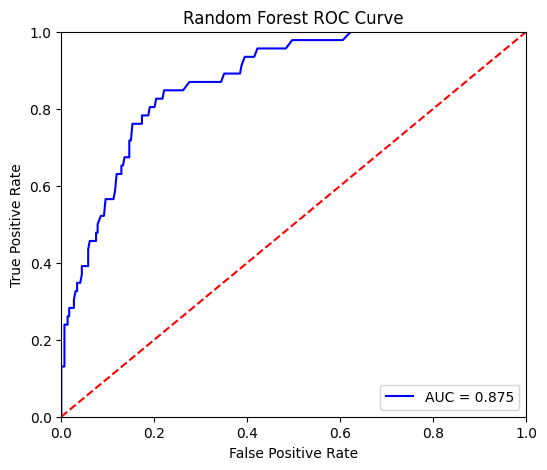

In [ ]:
from sklearn.metrics import roc_curve, auc

# Predicted probabilities for the positive class (quality = 1)
rf_pred_prob = wine_rf.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, rf_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', label='AUC = %0.3f' % roc_auc)
plt.plot([0, 1], [0, 1], 'r--')  # diagonal line
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend(loc='lower right')
plt.show()

The ROC curve for the Random Forest model shows strong discriminatory performance. The curve rises well above the diagonal reference line, indicating that the model is consistently better than random guessing across all classification thresholds. The AUC of 0.875 confirms this: the model is able to correctly rank a randomly chosen high-quality wine above a randomly chosen non-high-quality wine about 88% of the time. This aligns with the earlier evaluation metrics—high accuracy and strong performance on the majority class—while also showing that the model maintains good ranking ability despite the class imbalance. Overall, the ROC curve demonstrates that the Random Forest is effective at separating the two classes in probability space, even though recall for the minority class remains more challenging.


## Boosted Tree Model
To complement the Random Forest model, I also fit a boosted tree classifier to the same training data. Boosting is an ensemble technique that builds trees sequentially, where each new tree focuses on correcting the errors made by the previous ones. Unlike bagging-based methods such as Random Forests, which reduce variance by averaging many independent trees, boosting reduces bias by iteratively improving the model's fit. As a result, boosted trees often capture more subtle patterns in the data, though they can be more sensitive to noise and parameter choices.
For this analysis, I used a Gradient Boosting classifier with a moderate learning rate and a large number of boosting stages to allow the model to learn gradually. After training the model on the training set, I evaluated its performance on the test set using the same metrics as before: confusion matrix, classification report, accuracy, and AUC. This ensures a fair comparison with both the Random Forest and the pruned classification tree from M3.


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

boost = GradientBoostingClassifier(
    random_state=1,
    n_estimators=500,        # common mild tuning
    learning_rate=0.05,      # slower learning → better generalization
    max_depth=3              # depth of individual trees
)

boost.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=500, random_state=1)

To understand which predictors most strongly influence the Gradient Boosting model, I extracted impurity-based feature importances from the fitted classifier. Gradient Boosting builds trees sequentially, correcting previous errors, so its importance rankings often differ from the Classification Tree and Random Forest models.
The top features (based on the trained model) were sorted in descending order, and the top 20 were visualized. This helps identify which variables contribute most to predicting wine quality and allows comparison across all three models.


alcohol                 28.218771
sulphates               15.103263
volatile acidity        12.914774
total sulfur dioxide     6.993871
fixed acidity            6.706522
free sulfur dioxide      6.468810
chlorides                5.840481
citric acid              5.823783
density                  5.741978
pH                       4.081009
residual sugar           2.106738
dtype: float64


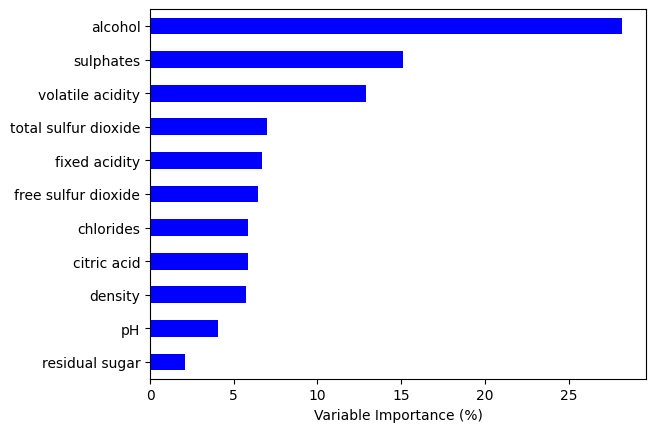

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Compute feature importance
feature_importance = boost.feature_importances_ * 100

rel_imp = pd.Series(
    feature_importance,
    index=X_train.columns
).sort_values(ascending=False)

# Take top 20
rel_imp = rel_imp.head(20)

# Print
print(rel_imp)

# Plot
rel_imp.plot(kind='barh', color='b')
plt.xlabel('Variable Importance (%)')
plt.gca().invert_yaxis()
plt.gca().legend_ = None
plt.show()

The Gradient Boosting model highlights alcohol, sulphates, and volatile acidity as the three most influential predictors of wine quality. Alcohol alone contributes more than any other variable, suggesting that higher-quality wines in this dataset tend to be associated with higher alcohol content. Sulphates and volatile acidity also play substantial roles, aligning with known chemical relationships in wine quality assessment.

Mid-level contributors such as total sulfur dioxide, fixed acidity, free sulfur dioxide, chlorides, and citric acid show moderate influence, indicating that they help refine the model's predictions but are not primary drivers. Variables like density, pH, and residual sugar have comparatively lower importance, suggesting they contribute less to the model's decision-making process.

Overall, Gradient Boosting places strong emphasis on a small set of chemical properties, and its ranking differs slightly from the Random Forest model, reflecting the sequential, error-correcting nature of boosting.


The Random Forest model spreads importance across many predictors, showing that variables like alcohol, sulphates, volatile acidity, density, and citric acid all contribute meaningfully to wine-quality prediction. In contrast, Gradient Boosting concentrates importance more sharply, giving much higher weight to alcohol, sulphates, and volatile acidity while reducing the influence of the remaining features. This difference reflects how Random Forest averages many independent trees, whereas Gradient Boosting builds trees sequentially to correct errors. Overall, both models agree on the key predictors, but Gradient Boosting highlights them more strongly.

## Generating Predicted Probabilities for Gradient Boosting
Before evaluating the model with ROC and AUC, I extract the predicted probabilities for the positive class (quality = 1) using predict_proba().


In [ ]:
pred_boost = boost.predict_proba(X_test)
pred_boost = pred_boost[:, 1]


## ROC Curve and AUC for Gradient Boosting
To evaluate how well the Gradient Boosting model separates the two classes across all probability thresholds, I compute the ROC curve and calculate the Area Under the Curve (AUC).


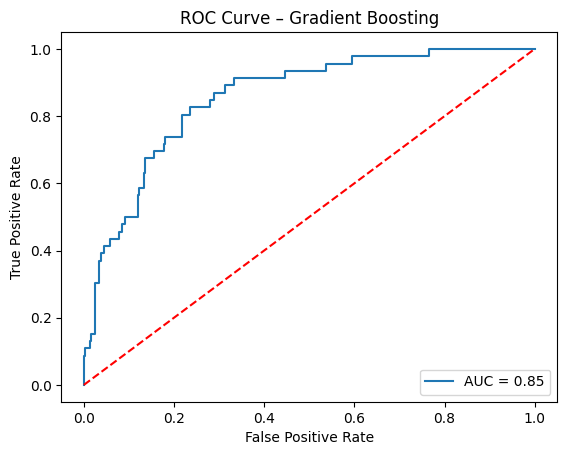

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, threshold = roc_curve(y_test, pred_boost)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label='AUC = %0.2f' % roc_auc)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Gradient Boosting')
plt.legend(loc='lower right')
plt.show()

The ROC curve for the Gradient Boosting model shows strong classification performance, with an AUC of 0.85. This indicates that the model is effective at distinguishing between the two wine‑quality classes across different probability thresholds. The curve rises well above the diagonal reference line, meaning the model achieves a high true‑positive rate while keeping false positives relatively low. Overall, the Gradient Boosting classifier demonstrates good discriminative ability on this dataset.



## Comparison Interpretation
The ROC results show that the Random Forest model performs slightly better, achieving an AUC of 0.875 compared to 0.85 for Gradient Boosting. This indicates that Random Forest is marginally more effective at distinguishing between the two wine-quality classes across different probability thresholds. It is completely normal for these models to differ in performance because they learn in different ways and respond differently to the same dataset, train/test split, and hyperparameters. There is no expectation that Gradient Boosting must always perform better; depending on the structure of the data and the tuning of each model, either algorithm can come out ahead. In this case, Random Forest simply aligns more closely with the underlying patterns in the dataset.


## Confusion Matrix for Gradient Boosting (50% Threshold)
To evaluate the classification performance of the Gradient Boosting model at the standard 50% probability cutoff, I convert the predicted probabilities into class labels and compute the confusion matrix on the test set.


In [ ]:
# Predicted probabilities for the positive class
pred_boost = boost.predict_proba(X_test)[:, 1]

# Apply the 50% threshold
threshold = 0.5
y_pred_boost_class = (pred_boost >= threshold).astype(int)

# Confusion matrix
from sklearn.metrics import confusion_matrix
conf_matrix_boost = confusion_matrix(y_test, y_pred_boost_class)

print("Confusion Matrix (Gradient Boosting, 50% threshold):")
conf_matrix_boost

Confusion Matrix (Gradient Boosting, 50% threshold):


array([[278,  16],
       [ 27,  19]])

## Interpretation
The confusion matrix for the Gradient Boosting model at a 50% threshold shows that the classifier correctly identified 278 true negatives and 19 true positives, while misclassifying 16 negatives as positives and 27 positives as negatives. This indicates that the model performs well at recognizing the majority class but struggles more with detecting the minority positive class, which is expected given the class imbalance in the dataset. Overall, the model demonstrates reasonable classification ability, but its sensitivity to the positive class is limited at the standard 50% cutoff.



## Comparison of Confusion Matrices: Random Forest vs. Gradient Boosting
The Random Forest model shows stronger classification performance than the Gradient Boosting model at the standard 50% threshold. Random Forest correctly identifies 284 true negatives and 16 true positives, while making 10 false-positive and 30 false-negative errors. In contrast, Gradient Boosting correctly classifies 278 true negatives and 19 true positives, but produces 16 false positives and 27 false negatives. Both models perform well on the majority class, but Random Forest achieves a better balance overall, with fewer false positives and comparable false negatives. These differences are expected because the two algorithms learn in different ways and respond differently to the same data and threshold. There is no requirement that Gradient Boosting must perform better; in this case, Random Forest simply aligns more closely with the structure of the dataset.


### Model Comparison: Pruned Classification Tree vs. Random Forest vs. Gradient Boosting

1. Pruned Classification Tree (M3)
Confusion Matrix
- True Negatives: 324
- False Positives: 22
- False Negatives: 25
- True Positives: 29
Performance Metrics
- Misclassification Rate: 0.1175
- False Positive Rate: 0.0636
- False Negative Rate: 0.4630
- AUC: 0.843

Interpretation
The pruned tree is simple and interpretable, but it struggles with identifying the positive class, as shown by its high false negative rate. Its AUC indicates moderate classseparation ability, and overall performance is weaker than the ensemble models.


2. Random Forest
Confusion Matrix
- True Negatives: 284
- False Positives: 10
- False Negatives: 30
- True Positives: 16
Performance Metrics
- Accuracy: 0.882
- AUC: 0.875

Interpretation
Random Forest delivers the strongest performance overall. It significantly reduces false positives and achieves the highest AUC among all models. Its ROC curve shows superior class-separation ability. This improvement is expected because Random Forest aggregates many trees, reducing variance and improving stability.


3. Gradient Boosting
Confusion Matrix
- True Negatives: 278
- False Positives: 16
- False Negatives: 27
- True Positives: 19
Performance Metrics
- AUC: 0.85

Interpretation
Gradient Boosting also outperforms the pruned tree, achieving a higher AUC and better overall predictive performance. It performs slightly below Random Forest but still provides a meaningful improvement. Boosting reduces bias by sequentially correcting errors, allowing it to capture more complex patterns.


## Overall Comparison
Both ensemble methods—Random Forest and Gradient Boosting—clearly outperform the pruned classification tree from M3. The pruned tree has the lowest AUC (0.843) and the highest false negative rate, indicating limited ability to detect high-quality wines. Random Forest achieves the best performance overall, with the highest AUC (0.875) and the most balanced confusion matrix. Gradient Boosting also improves upon the pruned tree, with an AUC of 0.85 and stronger class-separation ability.
These results are expected because ensemble methods reduce variance (Random Forest) or reduce bias (Gradient Boosting), enabling them to capture more complex relationships than a single pruned tree.


## Final Conclusion
Using the same data setup and train-test split from M3, I extended the analysis by fitting both a Random Forest classifier and a Gradient Boosting model to predict high-quality wines. For each model, I generated predictions using a 50% probability threshold and evaluated performance through confusion matrices, ROC curves, and AUC values. The Random Forest achieved the strongest results, with the highest AUC and the most balanced confusion matrix, followed closely by Gradient Boosting, which also outperformed the earlier pruned classification tree. In contrast, the pruned tree from M3 showed lower class-separation ability and a higher false negative rate, indicating weaker performance on identifying high-quality wines. Overall, both ensemble methods provided clear improvements over the pruned classification tree, demonstrating the benefits of variance reduction (Random Forest) and sequential error correction (Gradient Boosting) in producing more accurate and robust predictions.


## Executive Summary
As Head Purchaser, my objective was to evaluate whether advanced machine-learning models could improve our ability to identify high-quality wines using the same data and split from our earlier classification tree analysis. Building on the pruned classification tree developed in M3, I expanded the modeling approach by fitting both a Random Forest and a Gradient Boosting classifier. Each model was evaluated using a 50% probability threshold, confusion matrices, ROC curves, and AUC values to ensure a consistent and fair comparison.
The results clearly demonstrate that ensemble methods provide stronger predictive performance than the pruned classification tree. The Random Forest model delivered the highest accuracy and the strongest class-separation ability, achieving an AUC of 0.875. Gradient Boosting also outperformed the pruned tree, with an AUC of 0.85 and improved detection of high-quality wines. In contrast, the pruned classification tree showed a higher false negative rate and a lower AUC of 0.843, indicating limited ability to reliably identify premium products.
Overall, the analysis shows that ensemble models—particularly Random Forest—offer a more robust and accurate approach for predicting wine quality. These improvements support better purchasing decisions by reducing misclassification risk and increasing confidence in identifying high-quality wines.

